In [1]:
!pip install fastai torch torchvision -q


In [2]:
!pip install scikit-image -q

In [ ]:
import os, glob, math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch.utils.data import Dataset, DataLoader
from torchvision.models.resnet import resnet18
from fastai.vision.learner import create_body
from fastai.vision.models.unet import DynamicUnet
from skimage.color import lab2rgb
from skimage.metrics import peak_signal_noise_ratio as psnr_fn
from skimage.metrics import structural_similarity as ssim_fn
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True  
    torch.backends.cudnn.allow_tf32 = True          


Device: cuda
GPU: NVIDIA A100-SXM4-80GB
VRAM: 85.1 GB


##  Paths and Config

In [ ]:
DATA_DIR       = './colorization_data'
CHECKPOINT_DIR = './models_gan'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

BATCH_SIZE      = 192          
PRETRAIN_EPOCHS = 20
GAN_EPOCHS      = 30
TOTAL_EPOCHS    = PRETRAIN_EPOCHS + GAN_EPOCHS #  20 epochs (generator + L1 loss only), then 30 epochs (generator + discriminator)
LR_G            = 2e-4 * math.sqrt(192 / 32)  
LR_D            = 2e-4 * math.sqrt(192 / 32) 
LAMBDA_L1       = 100
SAVE_EVERY      = 5
SAMPLE_EVERY    = 5
IMG_SIZE        = 224
AMP_DTYPE       = torch.bfloat16 

print(f'Total epochs : {TOTAL_EPOCHS}  (Pretrain: {PRETRAIN_EPOCHS} + GAN: {GAN_EPOCHS})')
print(f'Batch size   : {BATCH_SIZE}')
print(f'AMP dtype    : {AMP_DTYPE}')
print(f'LR G/D       : {LR_G:.2e} / {LR_D:.2e}')


Total epochs : 50  (Pretrain: 20 + GAN: 30)
Batch size   : 192
AMP dtype    : torch.bfloat16
LR G/D       : 4.90e-04 / 4.90e-04


## Loading  Dataset  from drive ( We already did the train–validation-test split earlier and saved the processed data (L and AB channels) as .npy files on Google Drive. Here, we’re just loading those files directly into memory so we don’t have to redo preprocessing every time.)

drive link : https://drive.google.com/drive/folders/1e895ALAlIgyCWhuIqzfICEX2FITFqAbs

In [5]:
import os
import numpy as np

!pip install -q gdown
import gdown

DATA_DIR = './colorization_data'
os.makedirs(DATA_DIR, exist_ok=True)

files = {
    'train_L_norm.npy':  '1nHeHtlI4PgmNNDgZS0jgfanvOvERnh_x',
    'train_AB_norm.npy': '1YjJBj3gLleLTA8yxaDNm-benDf8Crfki',
    'val_L_norm.npy':    '1AGm7ExHvGo-_psK2uk4y_Py78Z1kA_jN',
    'val_AB_norm.npy':   '1-60zFHqsTYfI7sl9kRI7BcMOa8JWOGF7'
}

for fname, file_id in files.items():
    path = os.path.join(DATA_DIR, fname)
    if not os.path.exists(path):
        print(f'Downloading {fname}...')
        gdown.download(f'https://drive.google.com/uc?id={file_id}', path, quiet=False)
    else:
        print(f'{fname} already exists')


print('\nLoading dataset into RAM (no mmap)...')
train_L  = np.load(os.path.join(DATA_DIR, 'train_L_norm.npy'))
train_AB = np.load(os.path.join(DATA_DIR, 'train_AB_norm.npy'))
val_L    = np.load(os.path.join(DATA_DIR, 'val_L_norm.npy'))
val_AB   = np.load(os.path.join(DATA_DIR, 'val_AB_norm.npy'))

ram_mb = (train_L.nbytes + train_AB.nbytes + val_L.nbytes + val_AB.nbytes) / 1e6
print(f'RAM used by dataset : {ram_mb:.0f} MB')
print(f'Train L  : {train_L.shape}')
print(f'Train AB : {train_AB.shape}')
print(f'Val L    : {val_L.shape}')
print(f'Val AB   : {val_AB.shape}')


Downloading...
From (original): https://drive.google.com/uc?id=1nHeHtlI4PgmNNDgZS0jgfanvOvERnh_x
From (redirected): https://drive.google.com/uc?id=1nHeHtlI4PgmNNDgZS0jgfanvOvERnh_x&confirm=t&uuid=57ea5254-1492-4480-9ed5-895806334a28
To: /teamspace/studios/this_studio/colorization_data/train_L_norm.npy
100%|██████████| 4.01G/4.01G [00:28<00:00, 142MB/s] 


Downloading...
From (original): https://drive.google.com/uc?id=1YjJBj3gLleLTA8yxaDNm-benDf8Crfki
From (redirected): https://drive.google.com/uc?id=1YjJBj3gLleLTA8yxaDNm-benDf8Crfki&confirm=t&uuid=c8a61a0a-4fc5-4b71-987c-5684ad62bc98
To: /teamspace/studios/this_studio/colorization_data/train_AB_norm.npy
100%|██████████| 8.03G/8.03G [00:47<00:00, 167MB/s] 


Downloading...
From (original): https://drive.google.com/uc?id=1AGm7ExHvGo-_psK2uk4y_Py78Z1kA_jN
From (redirected): https://drive.google.com/uc?id=1AGm7ExHvGo-_psK2uk4y_Py78Z1kA_jN&confirm=t&uuid=c03e3a46-e473-4a2e-8017-026acd97634d
To: /teamspace/studios/this_studio/colorization_data/val_L_norm.npy
100%|██████████| 502M/502M [00:03<00:00, 166MB/s]  


Downloading...
From (original): https://drive.google.com/uc?id=1-60zFHqsTYfI7sl9kRI7BcMOa8JWOGF7
From (redirected): https://drive.google.com/uc?id=1-60zFHqsTYfI7sl9kRI7BcMOa8JWOGF7&confirm=t&uuid=f806846d-ed9c-4a12-9785-03cc5d097d78
To: /teamspace/studios/this_studio/colorization_data/val_AB_norm.npy
100%|██████████| 1.00G/1.00G [00:05<00:00, 168MB/s] 



Loading dataset into RAM (no mmap)...
RAM used by dataset : 13548 MB
Train L  : (20000, 224, 224)
Train AB : (20000, 224, 224, 2)
Val L    : (2500, 224, 224)
Val AB   : (2500, 224, 224, 2)


##Dataset & DataLoaders

In [ ]:
class ColorizationDataset(Dataset):

    def __init__(self, l_data, ab_data):
        self.l_data = l_data
        self.ab_data = ab_data

    def __len__(self):
        return len(self.l_data)

    def __getitem__(self, idx):

      
        l_t = torch.from_numpy(self.l_data[idx].copy()).float()
        ab_t = torch.from_numpy(self.ab_data[idx].copy()).float()

      
        if l_t.ndim == 2:
            l_t = l_t.unsqueeze(0)
        elif l_t.shape[-1] == 1:
            l_t = l_t.squeeze(-1).unsqueeze(0)


        if ab_t.ndim == 3 and ab_t.shape[-1] == 2:
            ab_t = ab_t.permute(2, 0, 1)

        return {
            'L': l_t,
            'ab': ab_t
        }



train_dataset = ColorizationDataset(train_L, train_AB)
val_dataset   = ColorizationDataset(val_L, val_AB)



train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=16,
    pin_memory=True,
    drop_last=True,
    persistent_workers=True,
    prefetch_factor=4
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=16,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=4
)



batch = next(iter(train_loader))

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")
print(f"L  shape: {batch['L'].shape}   range [{batch['L'].min():.2f}, {batch['L'].max():.2f}]")
print(f"AB shape: {batch['ab'].shape}  range [{batch['ab'].min():.2f}, {batch['ab'].max():.2f}]")

Train batches : 104 | Val batches : 14
L  : torch.Size([192, 1, 224, 224])   range [-1.00, 1.00]
AB : torch.Size([192, 2, 224, 224])  range [-0.66, 0.73]


## Model Architecture

#
Generator

Encoder: Uses a pre-trained ResNet18 to understand the image. We did not freeze it (no requires_grad = False), so it is fine-tuned during training

Decoder: Upsamples the features step by step to reconstruct the original image size without distortion.
Skip Connections: Links the encoder and decoder to pass high-resolution details, keeping the colors sharp and perfectly inside the lines.

Discriminator:
 We use a PatchGAN discriminator that looks at small patches of the image instead of the full image.


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import resnet18, ResNet18_Weights

class DecoderBlock(nn.Module):

    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels + skip_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x, skip):
        x = self.upsample(x)
        x = torch.cat([x, skip], dim=1)
        return self.conv(x)

class ResNet18Unet(nn.Module):
    def __init__(self, n_output=2):
        super().__init__()
       
        base = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        
       
        self.encoder_initial = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False),
            base.bn1,
            base.relu
        )
        self.maxpool = base.maxpool
        
        
        self.layer1 = base.layer1 # 64 channels, 56x56
        self.layer2 = base.layer2 # 128 channels, 28x28
        self.layer3 = base.layer3 # 256 channels, 14x14
        self.layer4 = base.layer4 # 512 channels, 7x7
        
        
        self.up1 = DecoderBlock(512, 256, 256)
      
        self.up2 = DecoderBlock(256, 128, 128)
       
        self.up3 = DecoderBlock(128, 64, 64)
        
        self.up4 = DecoderBlock(64, 64, 64)
        
       
        self.final_upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.final_conv = nn.Conv2d(64, n_output, kernel_size=1)
        
        self.sigmoid = nn.Tanh() 

    def forward(self, x):
      
        x1 = self.encoder_initial(x) 
        x_mp = self.maxpool(x1)      
        
        x2 = self.layer1(x_mp)      
        x3 = self.layer2(x2)         
        x4 = self.layer3(x3)        
        x5 = self.layer4(x4)         
        
        
        d1 = self.up1(x5, x4)        
        d2 = self.up2(d1, x3)        
        d3 = self.up3(d2, x2)        
        d4 = self.up4(d3, x1)       
        
        out = self.final_upsample(d4) 
        out = self.final_conv(out)    
        
        return out


def build_generator(n_input=1, n_output=2, size=224):
  
    model = ResNet18Unet(n_output=n_output).to(device)
    return model



class GANLoss(nn.Module):
    def __init__(self, real_label=1.0, fake_label=0.0):
        super().__init__()
        self.register_buffer('real_label', torch.tensor(real_label))
        self.register_buffer('fake_label', torch.tensor(fake_label))
        self.loss = nn.BCEWithLogitsLoss()

    def __call__(self, preds, target_is_real):
        labels = self.real_label if target_is_real else self.fake_label
        return self.loss(preds, labels.expand_as(preds))


#  Weight Initialization 
def init_weights(net, gain=0.02):
    def init_func(m):
        classname = m.__class__.__name__
        if hasattr(m, 'weight') and 'Conv' in classname:
            nn.init.normal_(m.weight.data, mean=0.0, std=gain)
            if hasattr(m, 'bias') and m.bias is not None:
                nn.init.constant_(m.bias.data, 0.0)
        elif 'BatchNorm2d' in classname:
            nn.init.normal_(m.weight.data, 1.0, gain)
            nn.init.constant_(m.bias.data, 0.0)
    net.apply(init_func)
    return net

#  Discriminator: PatchGAN 
class PatchDiscriminator(nn.Module):
    def __init__(self, input_c, num_filters=64, n_down=3):
        super().__init__()
        model  = [self.get_layers(input_c, num_filters, norm=False)]
        model += [self.get_layers(num_filters * 2**i,
                                   num_filters * 2**(i+1),
                                   s=1 if i == (n_down - 1) else 2)
                  for i in range(n_down)]
        model += [self.get_layers(num_filters * 2**n_down, 1,
                                   s=1, norm=False, act=False)]
        self.model = nn.Sequential(*model)

    def get_layers(self, ni, nf, k=4, s=2, p=1, norm=True, act=True):
        layers = [nn.Conv2d(ni, nf, k, s, p, bias=not norm)]
        if norm: layers += [nn.BatchNorm2d(nf)]
        if act:  layers += [nn.LeakyReLU(0.2, True)]
        return nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)


net_G    = build_generator(n_input=1, n_output=2, size=224)
net_D    = init_weights(PatchDiscriminator(input_c=3).to(device))
gan_loss = GANLoss().to(device)
l1_loss  = nn.L1Loss()


dummy = torch.randn(2, 1, 224, 224).to(device)
with torch.autocast(device_type='cuda', dtype=AMP_DTYPE):
    out = net_G(dummy)
print(f'Generator output shape: {out.shape}')  # Should be (2, 2, 224, 224)
print('Manual ResNet-UNet Models ready.')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /teamspace/studios/this_studio/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 152MB/s] 


Generator output shape: torch.Size([2, 2, 224, 224])
Models ready.


##  Visualization & Evaluation

#tensors_to_rgb: Converts model output from normalized LAB tensors back to RGB images for proper visualization

#Computes PSNR and SSIM to measure image quality

#Shows input grayscale, predicted color, and ground truth side by side

In [ ]:
def tensors_to_rgb(l_t, ab_t):
    # convert back from normalized tensors to  LAB to  RGB

    l_raw  = ((l_t + 1.0) / 2.0 * 255.0).permute(1, 2, 0).numpy()
    ab_raw = (ab_t * 128.0 + 128.0).permute(1, 2, 0).numpy()

    lab = np.concatenate([
        l_raw * (100.0 / 255.0),
        ab_raw - 128.0
    ], axis=-1)

    return lab2rgb(lab.astype(np.float64))


def visualize_samples(model, loader, epoch, n=4, tag=''):
    model.eval()

    batch = next(iter(loader))
    L_b  = batch['L'][:n].to(device)
    ab_b = batch['ab'][:n]

    with torch.no_grad(), torch.autocast(device_type='cuda', dtype=AMP_DTYPE):
        ab_fake = model(L_b).float().cpu()

    fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))

    for i in range(n):
        gray = (L_b[i].cpu().squeeze() + 1) / 2

        pred = np.clip(tensors_to_rgb(L_b[i].cpu(), ab_fake[i]), 0, 1)
        real = np.clip(tensors_to_rgb(L_b[i].cpu(), ab_b[i]),    0, 1)

        axes[i, 0].imshow(gray, cmap='gray')
        axes[i, 0].set_title('Input')
        axes[i, 0].axis('off')

        axes[i, 1].imshow(pred)
        axes[i, 1].set_title('Prediction')
        axes[i, 1].axis('off')

        axes[i, 2].imshow(real)
        axes[i, 2].set_title('Ground Truth')
        axes[i, 2].axis('off')

    plt.suptitle(f'{tag} | Epoch {epoch}', fontsize=13)
    plt.tight_layout()

    save_path = f'{CHECKPOINT_DIR}/{tag}_epoch_{epoch:04d}.png'
    plt.savefig(save_path, dpi=100, bbox_inches='tight')

    plt.show()
    model.train()


@torch.no_grad()
def evaluate(model, loader, max_batches=50):
    model.eval()

    all_psnr = []
    all_ssim = []

    for i, batch in enumerate(tqdm(loader, total=min(max_batches, len(loader)))):
        if i >= max_batches:
            break

        L_b  = batch['L'].to(device, non_blocking=True)
        ab_b = batch['ab']

        with torch.autocast(device_type='cuda', dtype=AMP_DTYPE):
            ab_pred = model(L_b).float().cpu()

        for j in range(L_b.shape[0]):
            pred = np.clip(tensors_to_rgb(L_b[j].cpu(), ab_pred[j]), 0, 1)
            real = np.clip(tensors_to_rgb(L_b[j].cpu(), ab_b[j]),    0, 1)

            all_psnr.append(psnr_fn(real, pred, data_range=1.0))
            all_ssim.append(
                ssim_fn(real, pred, data_range=1.0, channel_axis=2, win_size=7)
            )

    mean_psnr = np.mean(all_psnr)
    mean_ssim = np.mean(all_ssim)

    print(f'PSNR: {mean_psnr:.3f} dB | SSIM: {mean_ssim:.4f}')

    model.train()
    return mean_psnr, mean_ssim

In [1]:
train_losses = []  
val_losses   = []

## Stage 1: Pretrain Generator with L1 (20 Epochs)

First, we trained only the generator for 20 epochs using L1 loss to learn basic colorization.


Then, we trained the full GAN (generator + discriminator) for 30 epochs using GAN loss + L1 loss, where the discriminator learns real vs fake and the generator improves realism and details.

Starting pretrain from epoch 1.


Pretrain 1/20: 100%|██████████| 104/104 [01:00<00:00,  1.71it/s, l1=0.38775]


Pretrain Epoch 1 | Train L1=0.38775 | Val L1=0.08315


Pretrain 2/20: 100%|██████████| 104/104 [00:43<00:00,  2.37it/s, l1=0.07984]


Pretrain Epoch 2 | Train L1=0.07984 | Val L1=0.08093


...

Pretrain Epoch 3 | Train L1=0.07845 | Val L1=0.07922


Pretrain 4/20: 100%|██████████| 104/104 [00:44<00:00,  2.31it/s, l1=0.07759]


Pretrain Epoch 4 | Train L1=0.07759 | Val L1=0.07902


Pretrain 5/20: 100%|██████████| 104/104 [00:44<00:00,  2.32it/s, l1=0.07709]


Pretrain Epoch 5 | Train L1=0.07709 | Val L1=0.07889


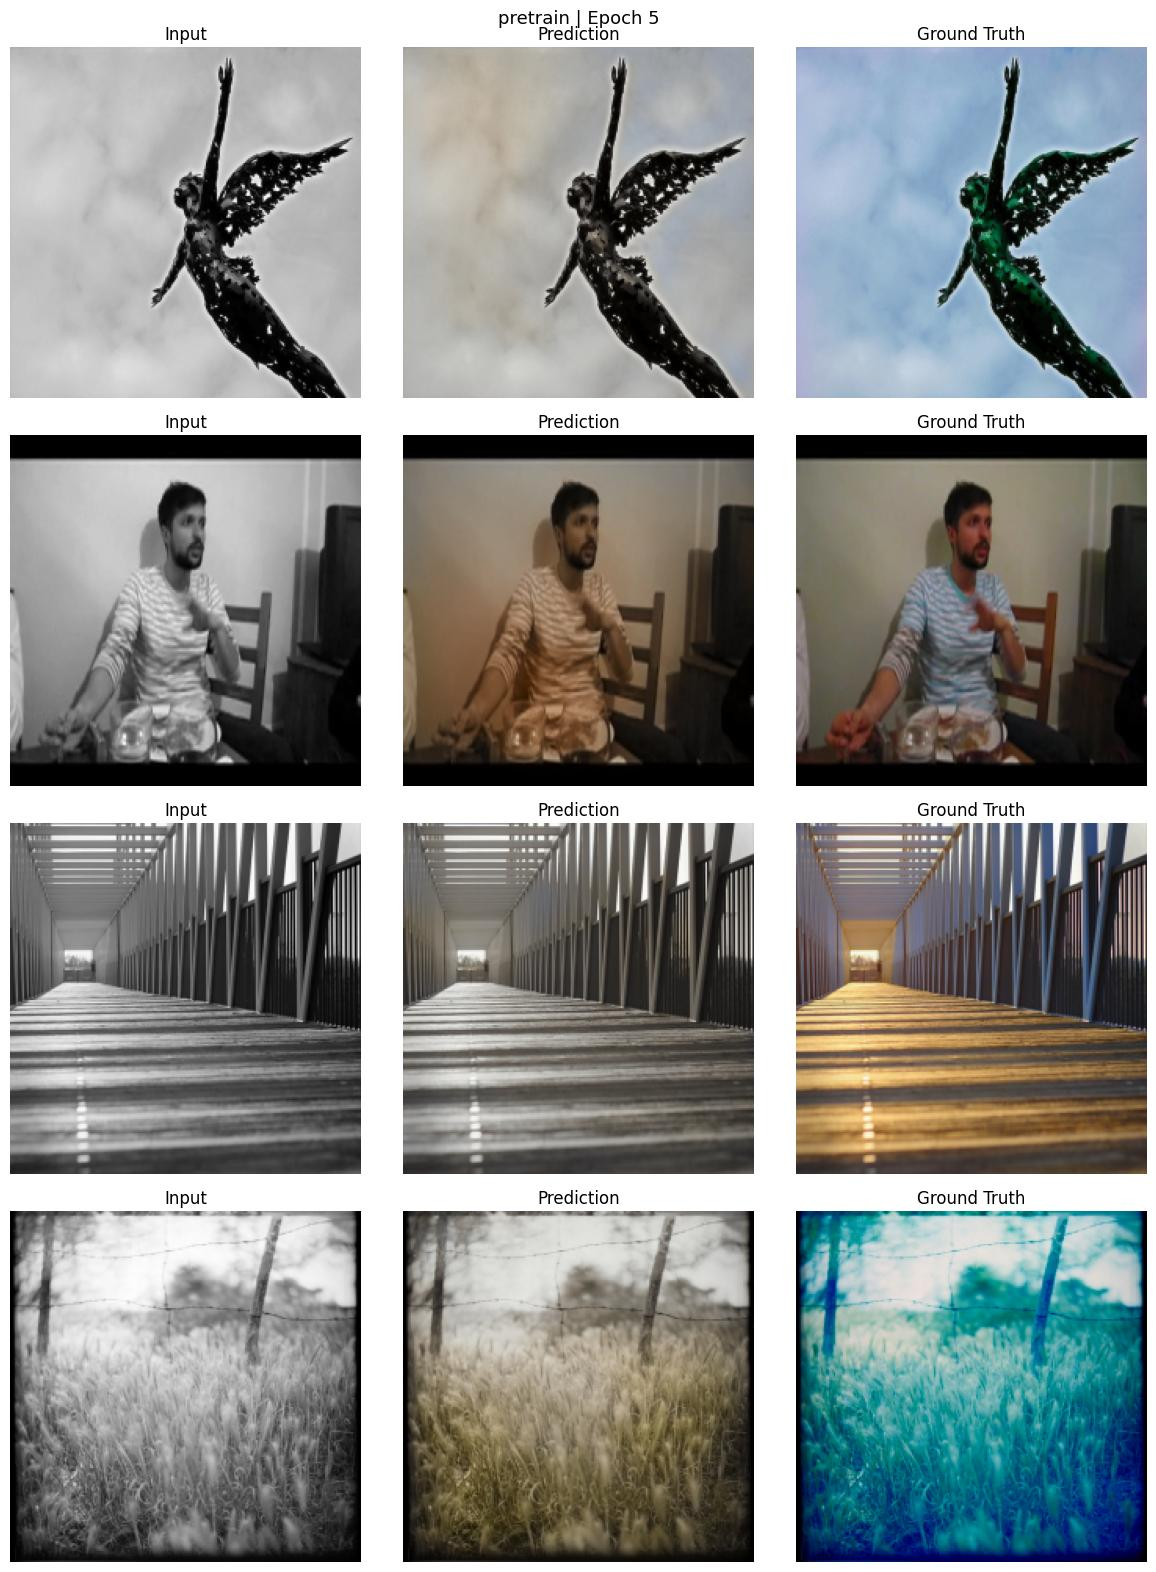

Saved: ./models_gan/gan_epoch_0005.pt


Pretrain 6/20: 100%|██████████| 104/104 [00:44<00:00,  2.34it/s, l1=0.07638]


Pretrain Epoch 6 | Train L1=0.07638 | Val L1=0.07840


Pretrain 7/20: 100%|██████████| 104/104 [00:43<00:00,  2.38it/s, l1=0.07546]


Pretrain Epoch 7 | Train L1=0.07546 | Val L1=0.07842


...

Pretrain Epoch 8 | Train L1=0.07414 | Val L1=0.07929


Pretrain 9/20: 100%|██████████| 104/104 [00:44<00:00,  2.35it/s, l1=0.07275]


Pretrain Epoch 9 | Train L1=0.07275 | Val L1=0.07971


Pretrain 10/20: 100%|██████████| 104/104 [00:44<00:00,  2.33it/s, l1=0.07126]


Pretrain Epoch 10 | Train L1=0.07126 | Val L1=0.07879


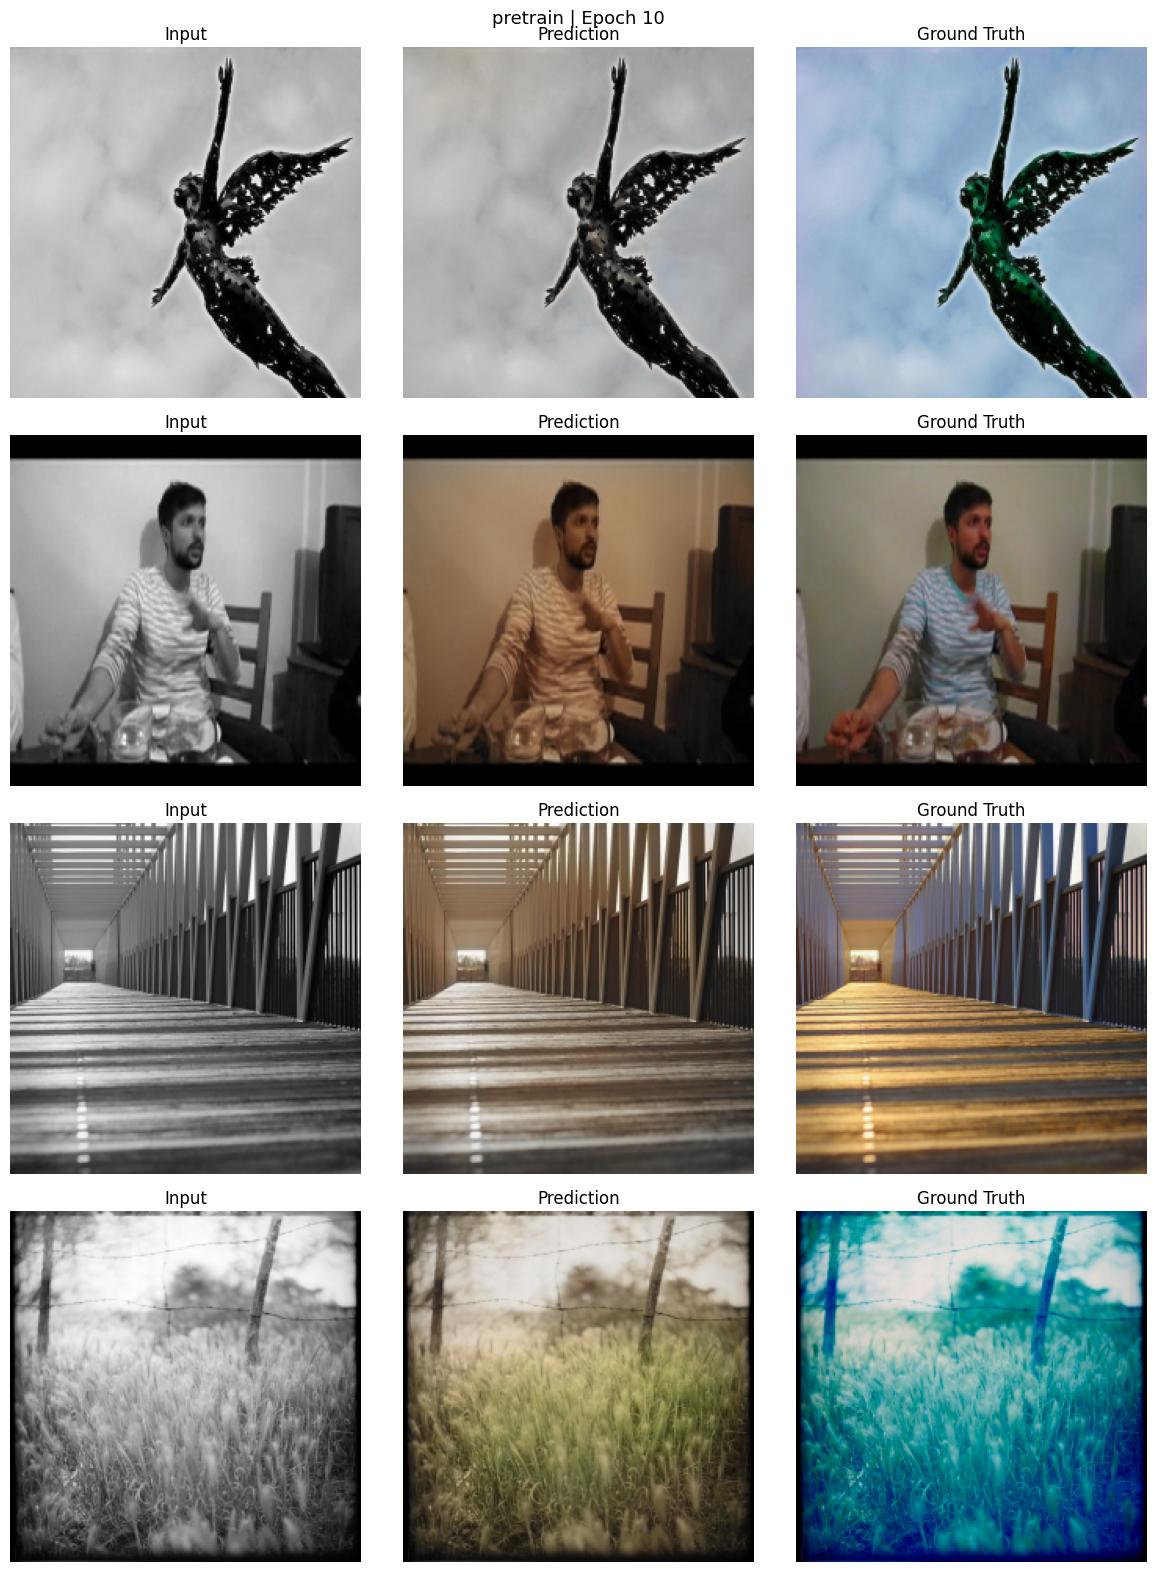

Saved: ./models_gan/gan_epoch_0010.pt


Pretrain 11/20: 100%|██████████| 104/104 [00:43<00:00,  2.37it/s, l1=0.06940]


Pretrain Epoch 11 | Train L1=0.06940 | Val L1=0.08696


Pretrain 12/20: 100%|██████████| 104/104 [00:44<00:00,  2.32it/s, l1=0.06801]


Pretrain Epoch 12 | Train L1=0.06801 | Val L1=0.08161


...

Pretrain Epoch 13 | Train L1=0.06615 | Val L1=0.07955


Pretrain 14/20: 100%|██████████| 104/104 [00:44<00:00,  2.36it/s, l1=0.06515]


Pretrain Epoch 14 | Train L1=0.06515 | Val L1=0.08059


Pretrain 15/20: 100%|██████████| 104/104 [00:45<00:00,  2.30it/s, l1=0.06361]


Pretrain Epoch 15 | Train L1=0.06361 | Val L1=0.08158


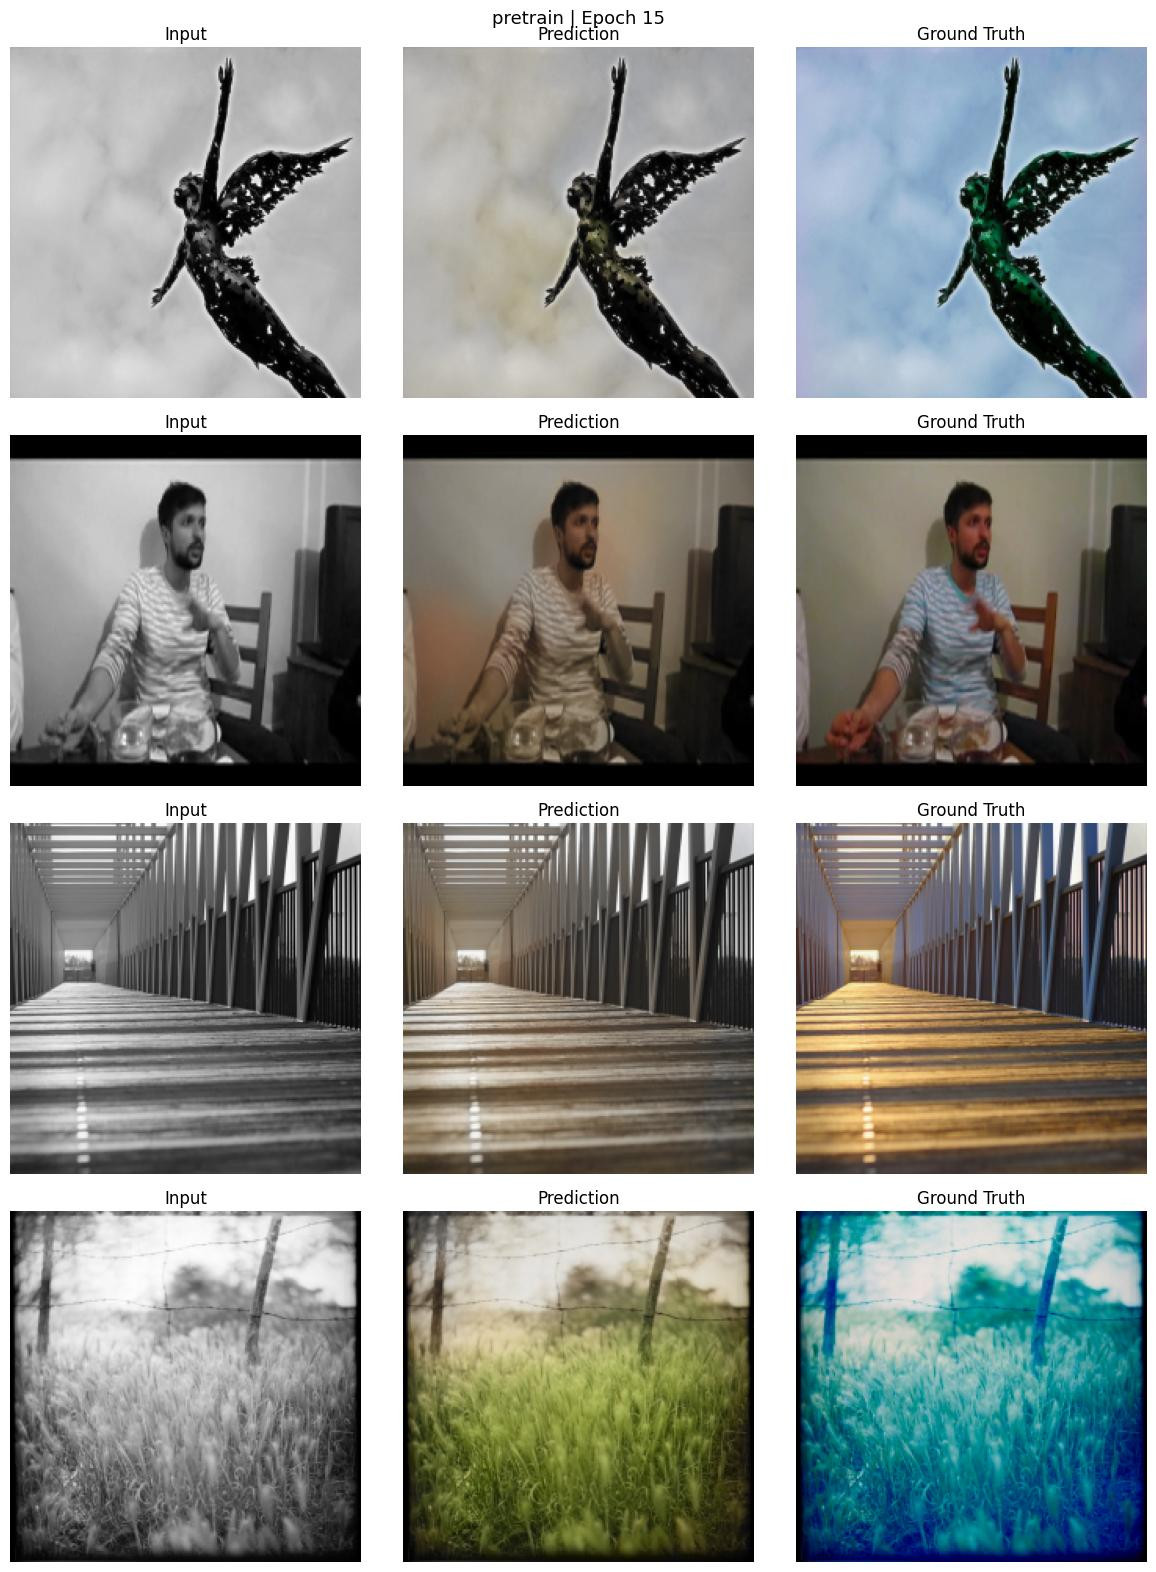

Saved: ./models_gan/gan_epoch_0015.pt


Pretrain 16/20: 100%|██████████| 104/104 [00:44<00:00,  2.36it/s, l1=0.06246]


Pretrain Epoch 16 | Train L1=0.06246 | Val L1=0.08069


Pretrain 17/20: 100%|██████████| 104/104 [00:44<00:00,  2.36it/s, l1=0.06110]


Pretrain Epoch 17 | Train L1=0.06110 | Val L1=0.07978


...

Pretrain Epoch 18 | Train L1=0.06040 | Val L1=0.08171


Pretrain 19/20: 100%|██████████| 104/104 [00:44<00:00,  2.32it/s, l1=0.05932]


Pretrain Epoch 19 | Train L1=0.05932 | Val L1=0.08009


Pretrain 20/20: 100%|██████████| 104/104 [00:44<00:00,  2.34it/s, l1=0.05858]


Pretrain Epoch 20 | Train L1=0.05858 | Val L1=0.08073


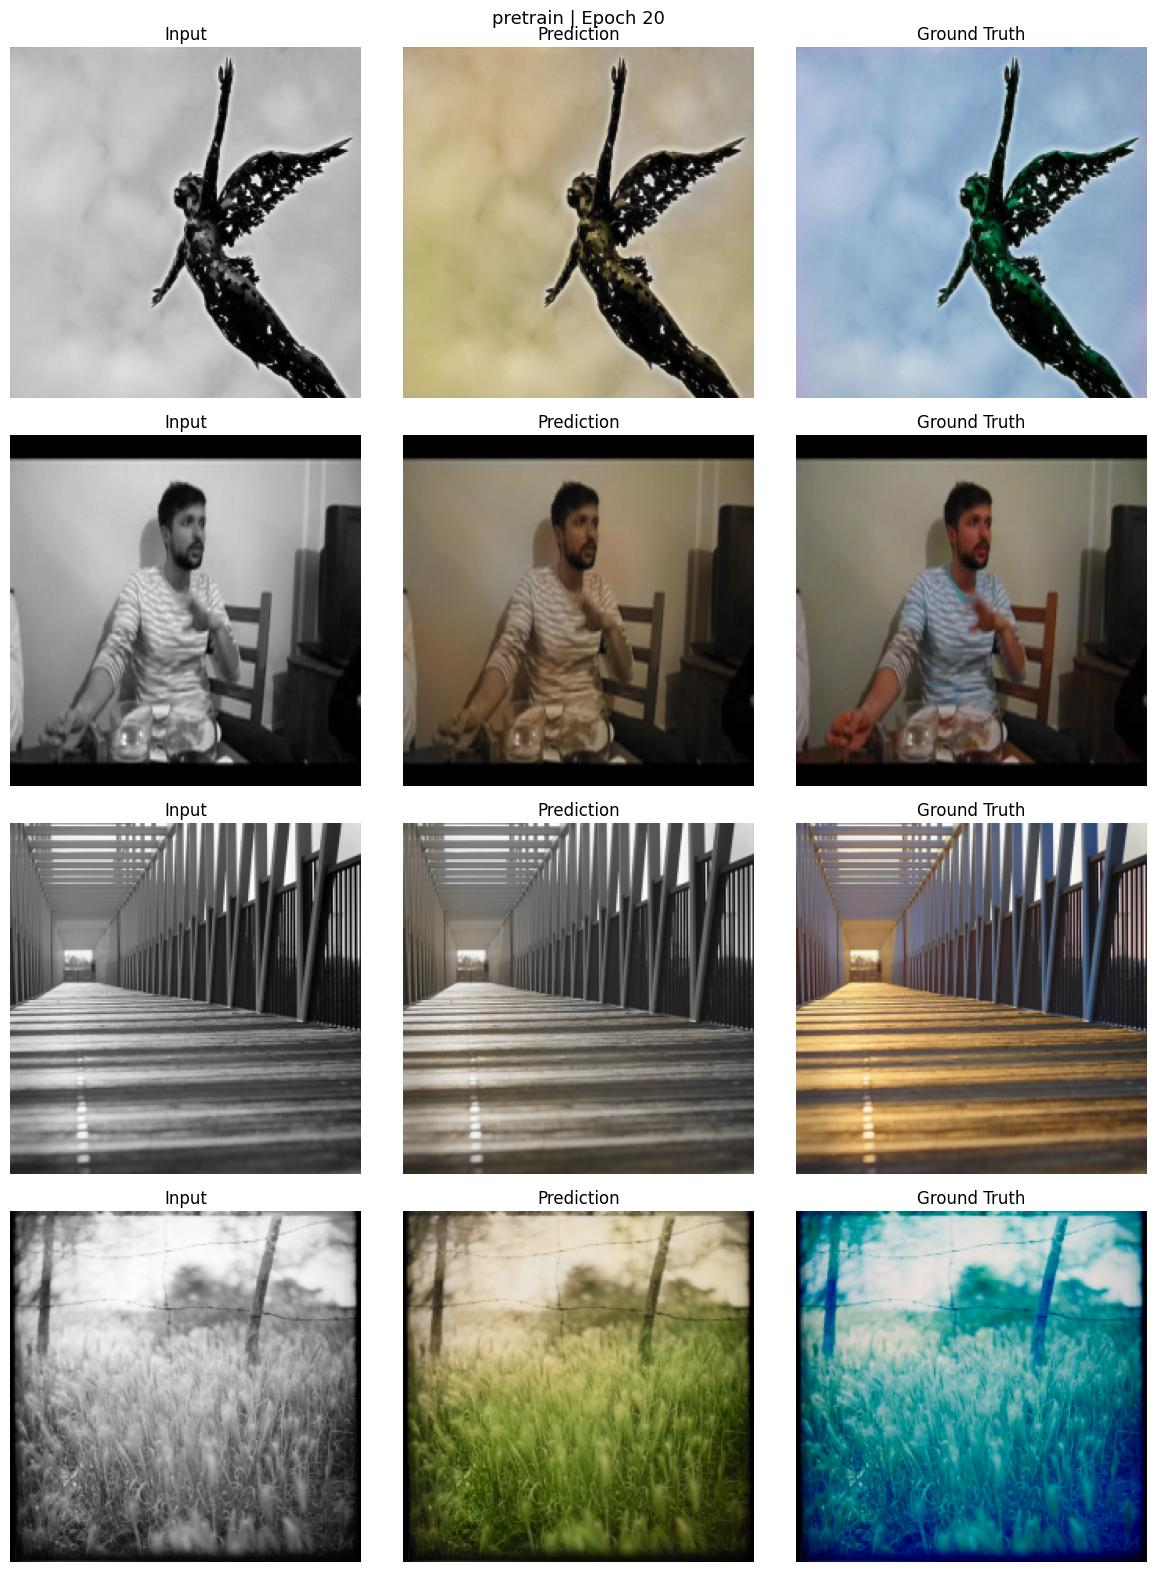

Saved: ./models_gan/gan_epoch_0020.pt
Pretrained generator saved to ./models_gan/pretrained_generator.pt


In [ ]:
opt_G_pre = optim.Adam(net_G.parameters(), lr=6e-4)  

pretrain_ckpt = os.path.join(CHECKPOINT_DIR, 'pretrained_generator.pt')
pretrain_start = 0

print('Starting pretrain from epoch 1.')

for epoch in range(pretrain_start, PRETRAIN_EPOCHS):
    net_G.train()
    epoch_l1 = []

    pbar = tqdm(train_loader, desc=f'Pretrain {epoch+1}/{PRETRAIN_EPOCHS}')
    for batch in pbar:
        L_b  = batch['L'].to(device, non_blocking=True)
        ab_b = batch['ab'].to(device, non_blocking=True)

        with torch.autocast(device_type='cuda', dtype=AMP_DTYPE):
            ab_pred = net_G(L_b)
            loss    = l1_loss(ab_pred, ab_b)

        opt_G_pre.zero_grad(set_to_none=True)  
        loss.backward()
        opt_G_pre.step()

        epoch_l1.append(loss.item())
        pbar.set_postfix(l1=f'{np.mean(epoch_l1):.5f}')

    net_G.eval()
    val_l1 = []
    with torch.no_grad(), torch.autocast(device_type='cuda', dtype=AMP_DTYPE):
        for batch in val_loader:
            L_b  = batch['L'].to(device, non_blocking=True)
            ab_b = batch['ab'].to(device, non_blocking=True)
            val_l1.append(l1_loss(net_G(L_b), ab_b).item())

    avg_train = np.mean(epoch_l1)
    avg_val   = np.mean(val_l1)
    train_losses.append({'l1': avg_train, 'G': None, 'D': None})
    val_losses.append(  {'l1': avg_val,   'G': None, 'D': None})

    print(f'Pretrain Epoch {epoch+1} | Train L1={avg_train:.5f} | Val L1={avg_val:.5f}')

    if (epoch + 1) % SAMPLE_EVERY == 0:
        visualize_samples(net_G, val_loader, epoch + 1, tag='pretrain')

torch.save(net_G.state_dict(), pretrain_ckpt)
print(f'Pretrained generator saved to {pretrain_ckpt}')

##  Stage 2: GAN Fine-tuning (30 Epochs)

Loaded pretrained generator.
Starting GAN from epoch 1.
STAGE 2 — GAN Fine-tuning (GAN + L1 loss)


GAN 1/30: 100%|██████████| 104/104 [00:53<00:00,  1.93it/s, D=0.6105, G=6.8860, l1=0.06268]


GAN Epoch 1 | G=6.8860 | D=0.6105 | L1=0.06268 | Val L1=0.08053


GAN 2/30: 100%|██████████| 104/104 [00:53<00:00,  1.94it/s, D=0.4671, G=6.9185, l1=0.06463]


GAN Epoch 2 | G=6.9185 | D=0.4671 | L1=0.06463 | Val L1=0.08513


...

GAN Epoch 3 | G=6.6075 | D=0.4280 | L1=0.06260 | Val L1=0.08454


GAN 4/30: 100%|██████████| 104/104 [00:55<00:00,  1.89it/s, D=0.4227, G=6.4206, l1=0.06132]


GAN Epoch 4 | G=6.4206 | D=0.4227 | L1=0.06132 | Val L1=0.08112


GAN 5/30: 100%|██████████| 104/104 [00:54<00:00,  1.92it/s, D=0.4766, G=6.3642, l1=0.06043]


GAN Epoch 5 | G=6.3642 | D=0.4766 | L1=0.06043 | Val L1=0.07940


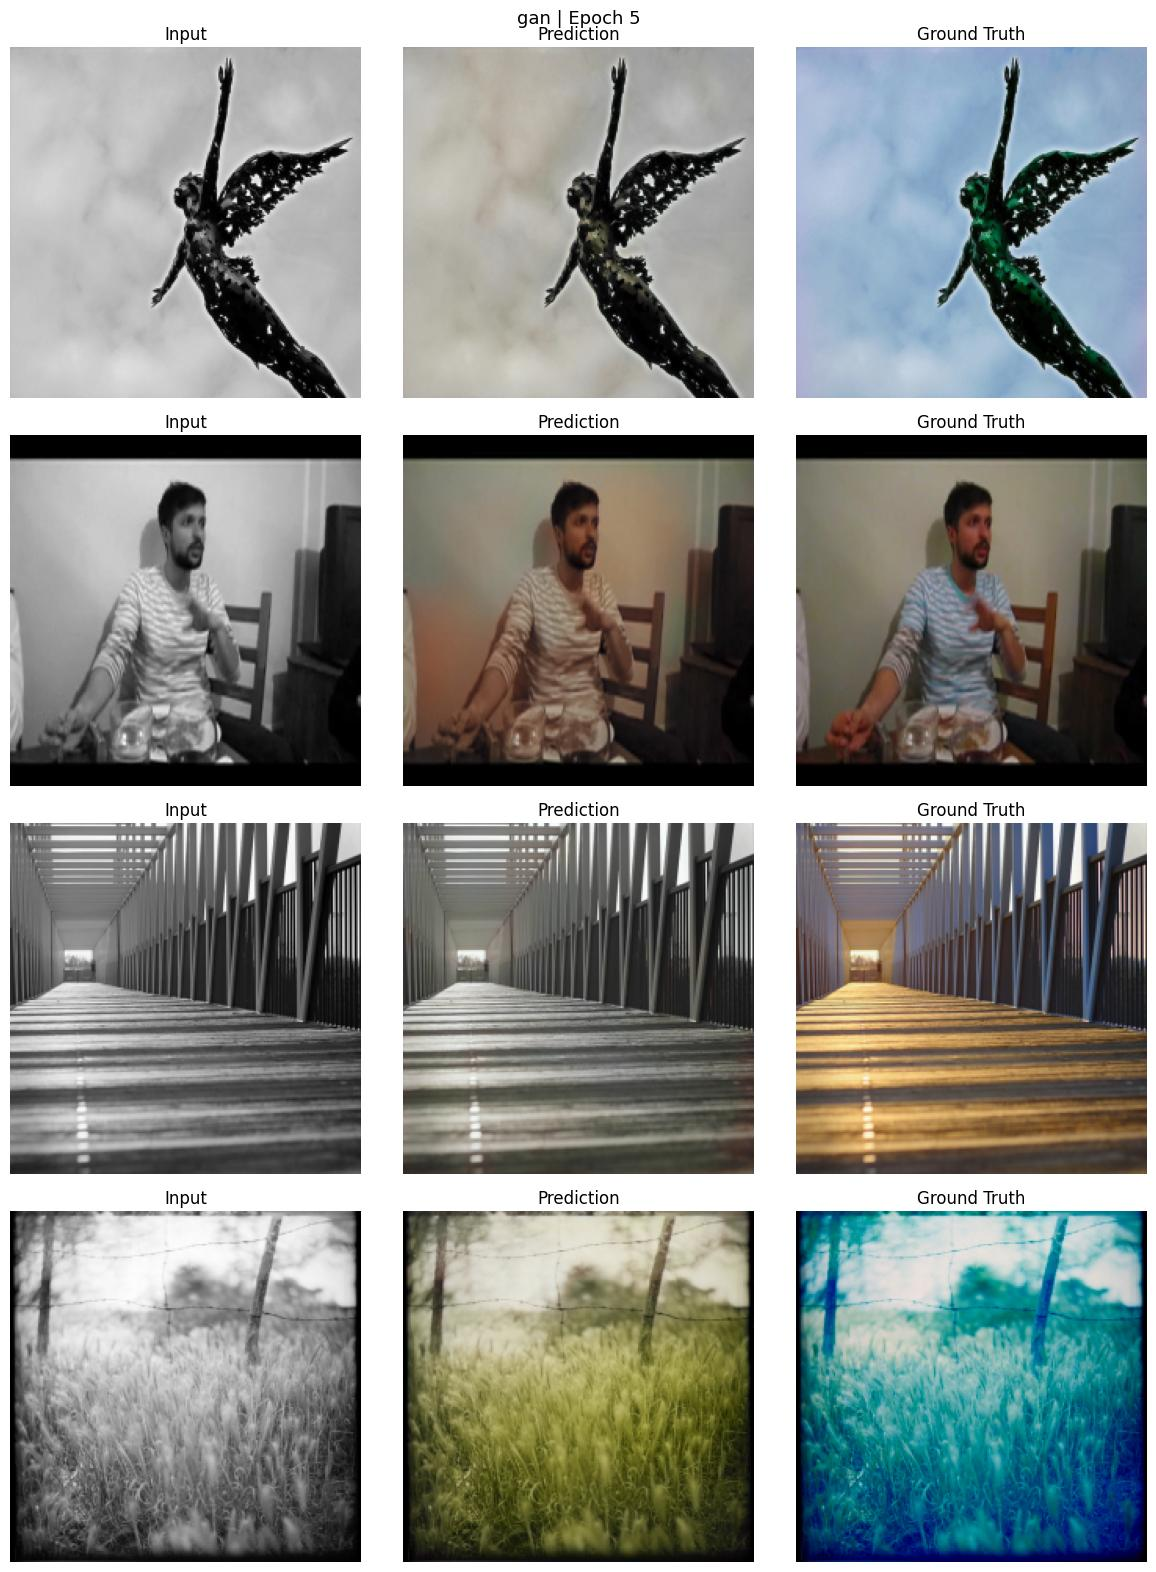

Saved: ./models_gan/gan_epoch_0005.pt


GAN 6/30: 100%|██████████| 104/104 [00:54<00:00,  1.91it/s, D=0.4123, G=6.2051, l1=0.05979]


GAN Epoch 6 | G=6.2051 | D=0.4123 | L1=0.05979 | Val L1=0.08150


GAN 7/30: 100%|██████████| 104/104 [00:54<00:00,  1.92it/s, D=0.4695, G=6.1735, l1=0.05870]


GAN Epoch 7 | G=6.1735 | D=0.4695 | L1=0.05870 | Val L1=0.08241


...

GAN Epoch 8 | G=6.0281 | D=0.4222 | L1=0.05777 | Val L1=0.07964


GAN 9/30: 100%|██████████| 104/104 [00:54<00:00,  1.92it/s, D=0.4536, G=6.1994, l1=0.05862]


GAN Epoch 9 | G=6.1994 | D=0.4536 | L1=0.05862 | Val L1=0.08005


GAN 10/30: 100%|██████████| 104/104 [00:53<00:00,  1.95it/s, D=0.4644, G=5.9811, l1=0.05650]


GAN Epoch 10 | G=5.9811 | D=0.4644 | L1=0.05650 | Val L1=0.08010


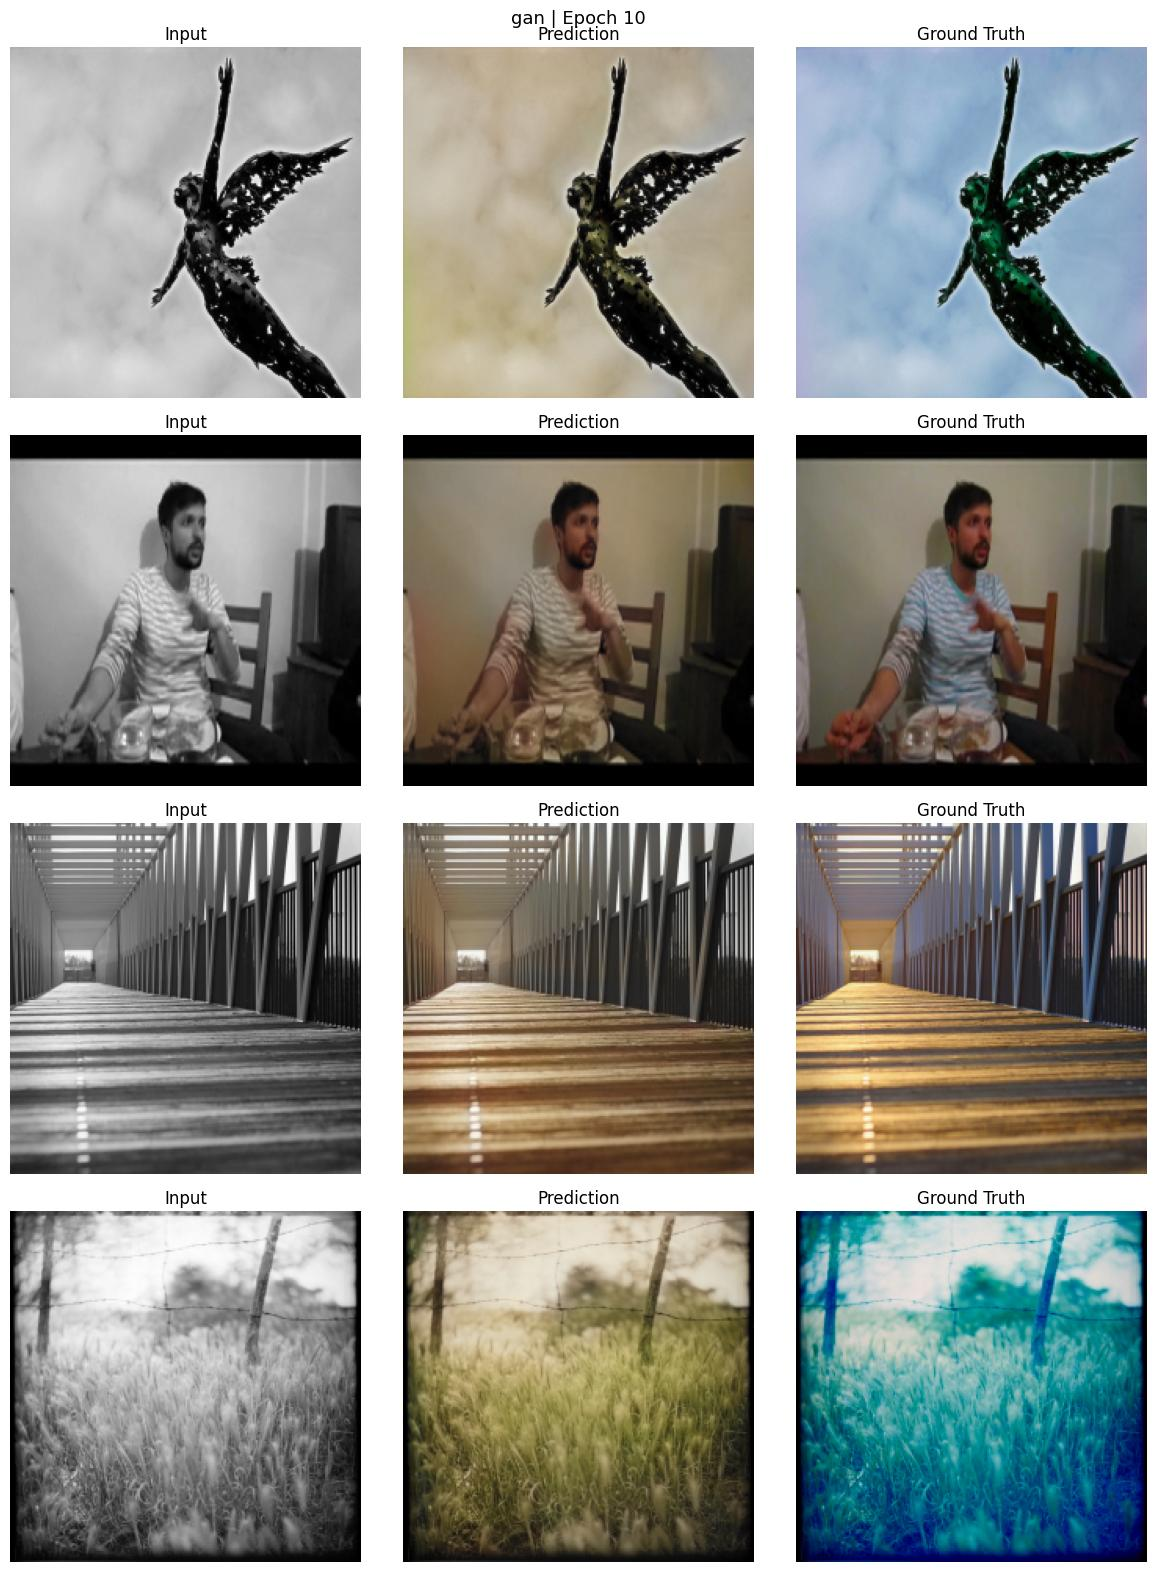

Saved: ./models_gan/gan_epoch_0010.pt


GAN 11/30: 100%|██████████| 104/104 [00:53<00:00,  1.93it/s, D=0.4344, G=5.8025, l1=0.05522]


GAN Epoch 11 | G=5.8025 | D=0.4344 | L1=0.05522 | Val L1=0.08175


GAN 12/30: 100%|██████████| 104/104 [00:53<00:00,  1.93it/s, D=0.4312, G=5.5901, l1=0.05353]


GAN Epoch 12 | G=5.5901 | D=0.4312 | L1=0.05353 | Val L1=0.07888


...

GAN Epoch 13 | G=5.5998 | D=0.4667 | L1=0.05294 | Val L1=0.08003


GAN 14/30: 100%|██████████| 104/104 [00:53<00:00,  1.95it/s, D=0.4467, G=5.4331, l1=0.05185]


GAN Epoch 14 | G=5.4331 | D=0.4467 | L1=0.05185 | Val L1=0.08122


GAN 15/30: 100%|██████████| 104/104 [00:53<00:00,  1.94it/s, D=0.4866, G=5.4735, l1=0.05173]


GAN Epoch 15 | G=5.4735 | D=0.4866 | L1=0.05173 | Val L1=0.08016


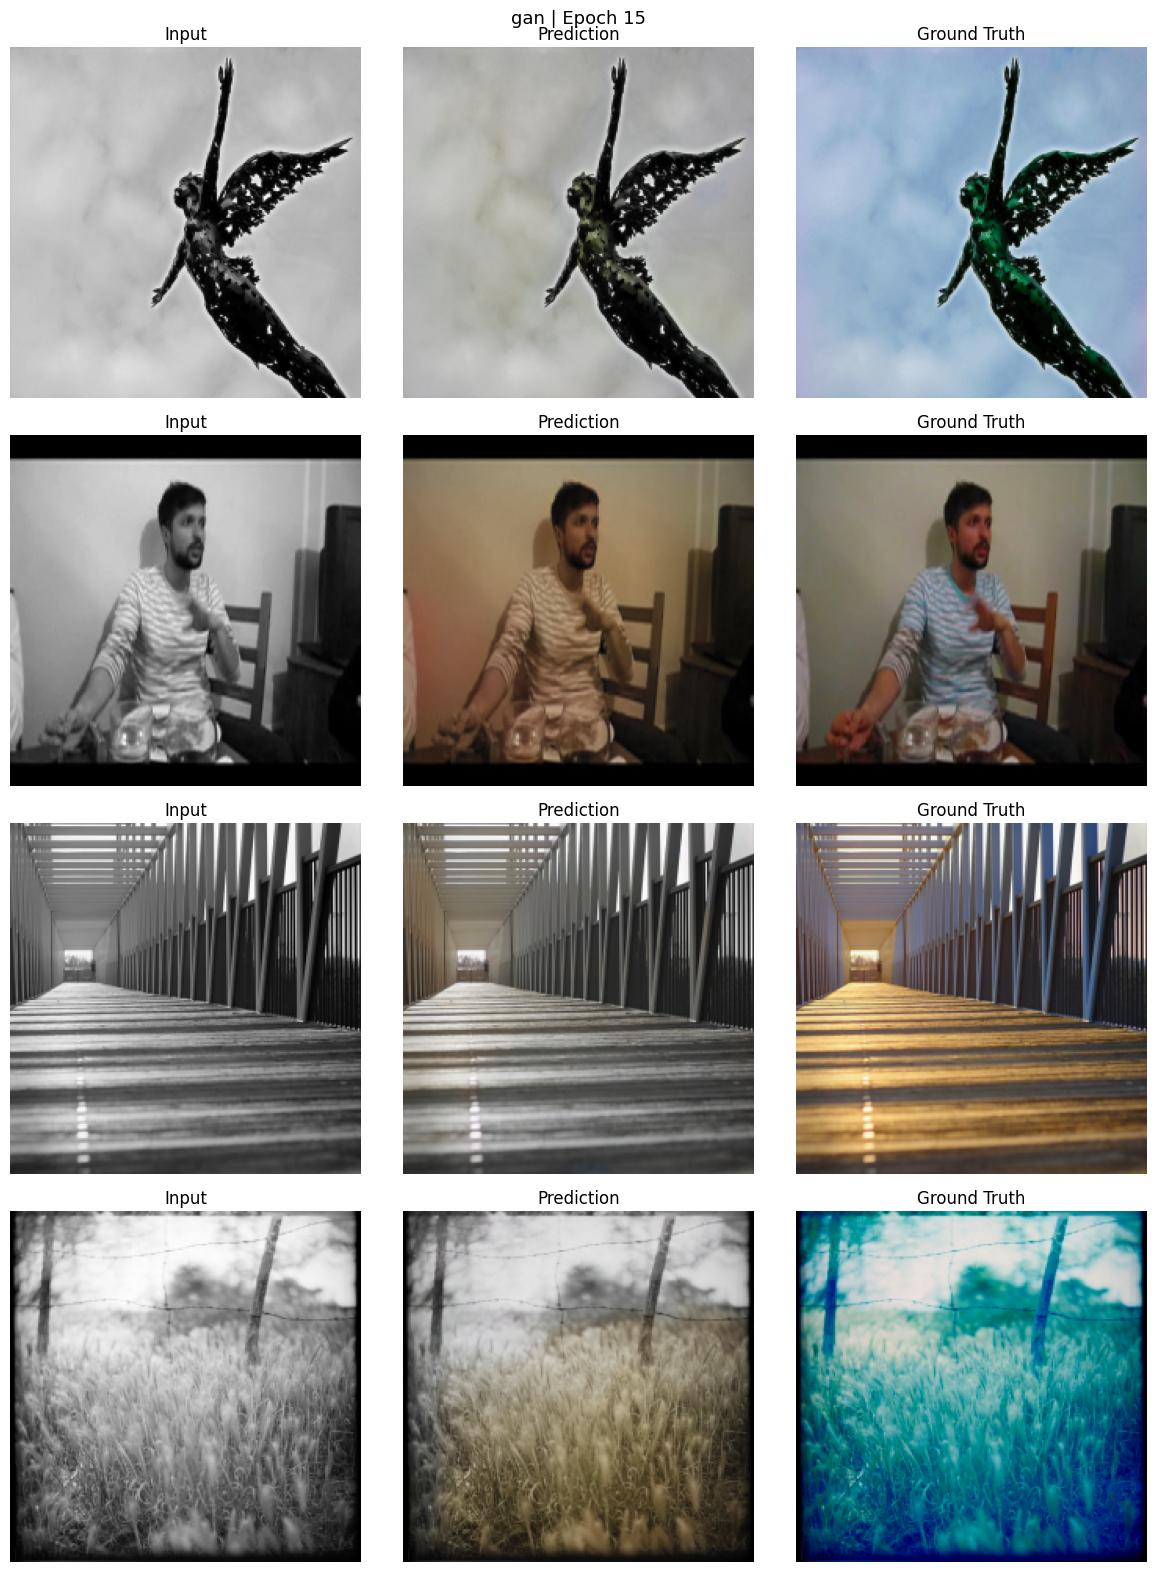

Saved: ./models_gan/gan_epoch_0015.pt


GAN 16/30: 100%|██████████| 104/104 [00:53<00:00,  1.93it/s, D=0.5108, G=5.4734, l1=0.05142]


GAN Epoch 16 | G=5.4734 | D=0.5108 | L1=0.05142 | Val L1=0.08075


GAN 17/30: 100%|██████████| 104/104 [00:54<00:00,  1.92it/s, D=0.4566, G=5.3635, l1=0.05119]


GAN Epoch 17 | G=5.3635 | D=0.4566 | L1=0.05119 | Val L1=0.08126


...

GAN Epoch 18 | G=5.2565 | D=0.4231 | L1=0.05004 | Val L1=0.08832


GAN 19/30: 100%|██████████| 104/104 [00:54<00:00,  1.91it/s, D=0.4406, G=5.2885, l1=0.05046]


GAN Epoch 19 | G=5.2885 | D=0.4406 | L1=0.05046 | Val L1=0.08015


GAN 20/30: 100%|██████████| 104/104 [00:54<00:00,  1.92it/s, D=0.3587, G=5.0128, l1=0.04851]


GAN Epoch 20 | G=5.0128 | D=0.3587 | L1=0.04851 | Val L1=0.08037


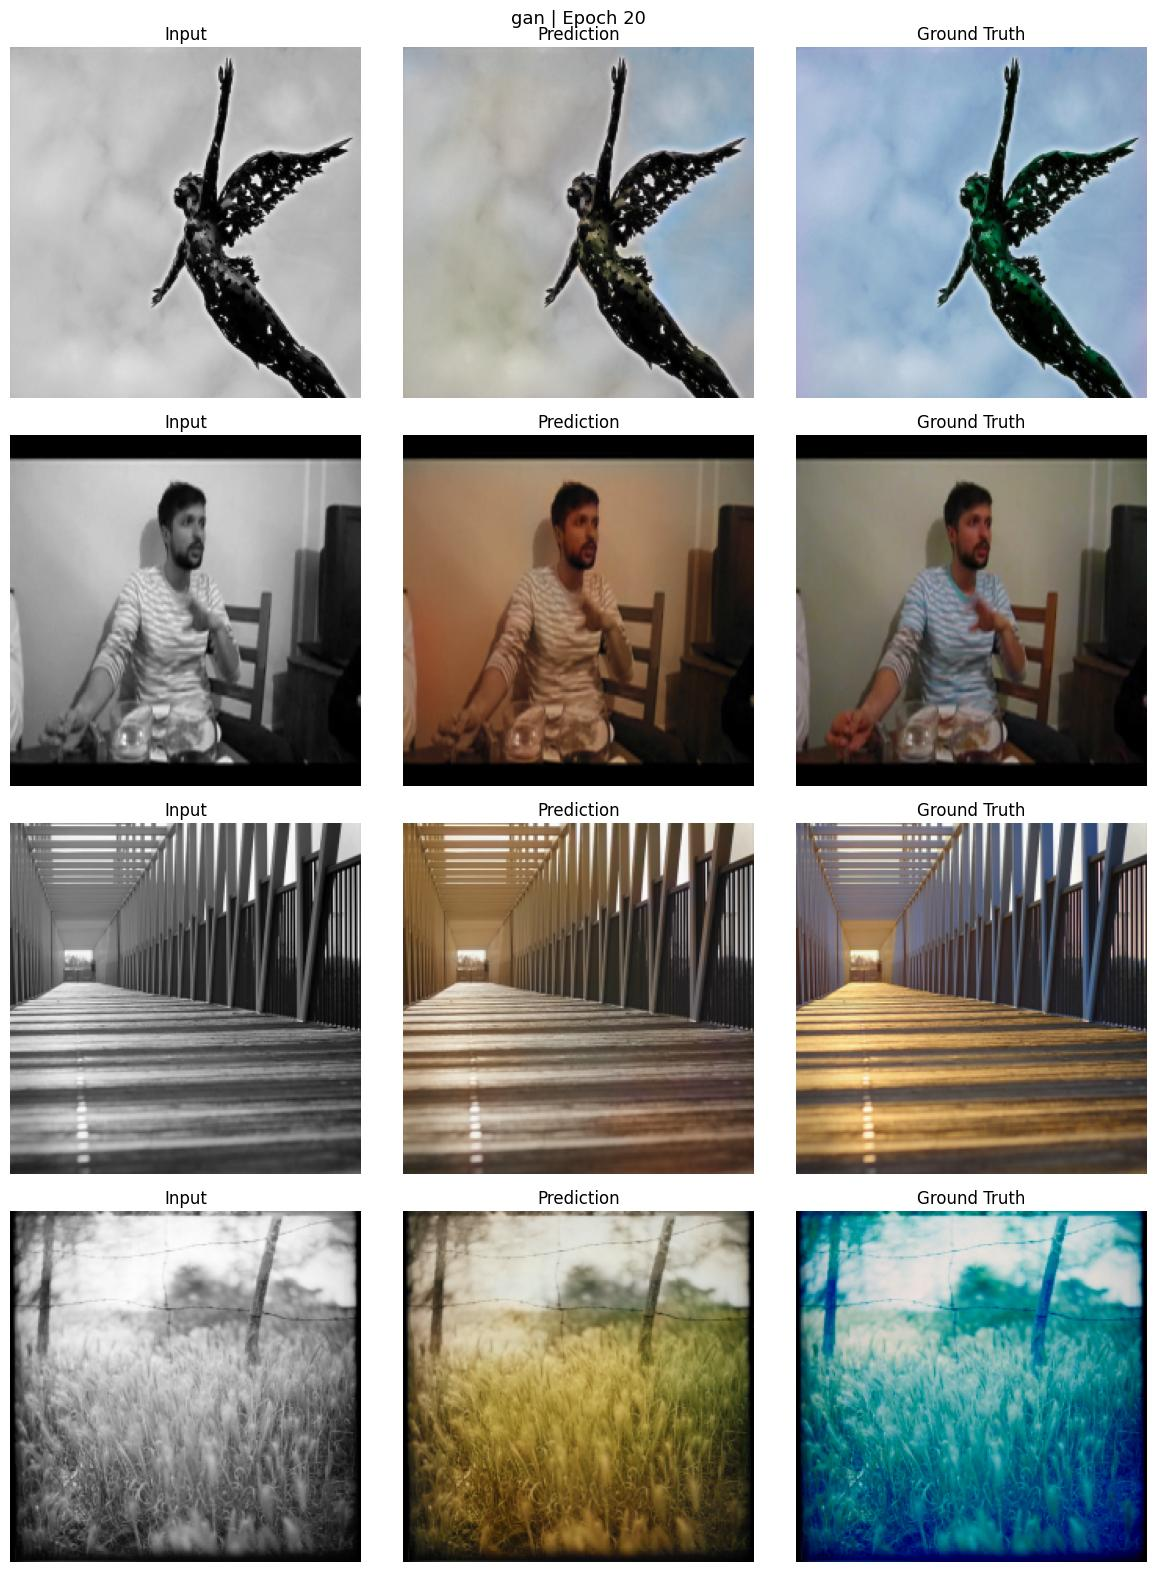

Saved: ./models_gan/gan_epoch_0020.pt


GAN 21/30: 100%|██████████| 104/104 [00:54<00:00,  1.90it/s, D=0.3478, G=4.9422, l1=0.04763]


GAN Epoch 21 | G=4.9422 | D=0.3478 | L1=0.04763 | Val L1=0.07997


GAN 22/30: 100%|██████████| 104/104 [00:54<00:00,  1.91it/s, D=0.3404, G=4.9107, l1=0.04732]


GAN Epoch 22 | G=4.9107 | D=0.3404 | L1=0.04732 | Val L1=0.08011


...

GAN Epoch 23 | G=4.9848 | D=0.3865 | L1=0.04693 | Val L1=0.07993


GAN 24/30: 100%|██████████| 104/104 [00:54<00:00,  1.92it/s, D=0.3875, G=4.9084, l1=0.04656]


GAN Epoch 24 | G=4.9084 | D=0.3875 | L1=0.04656 | Val L1=0.08047


GAN 25/30: 100%|██████████| 104/104 [00:53<00:00,  1.96it/s, D=0.4370, G=4.8886, l1=0.04608]


GAN Epoch 25 | G=4.8886 | D=0.4370 | L1=0.04608 | Val L1=0.08008


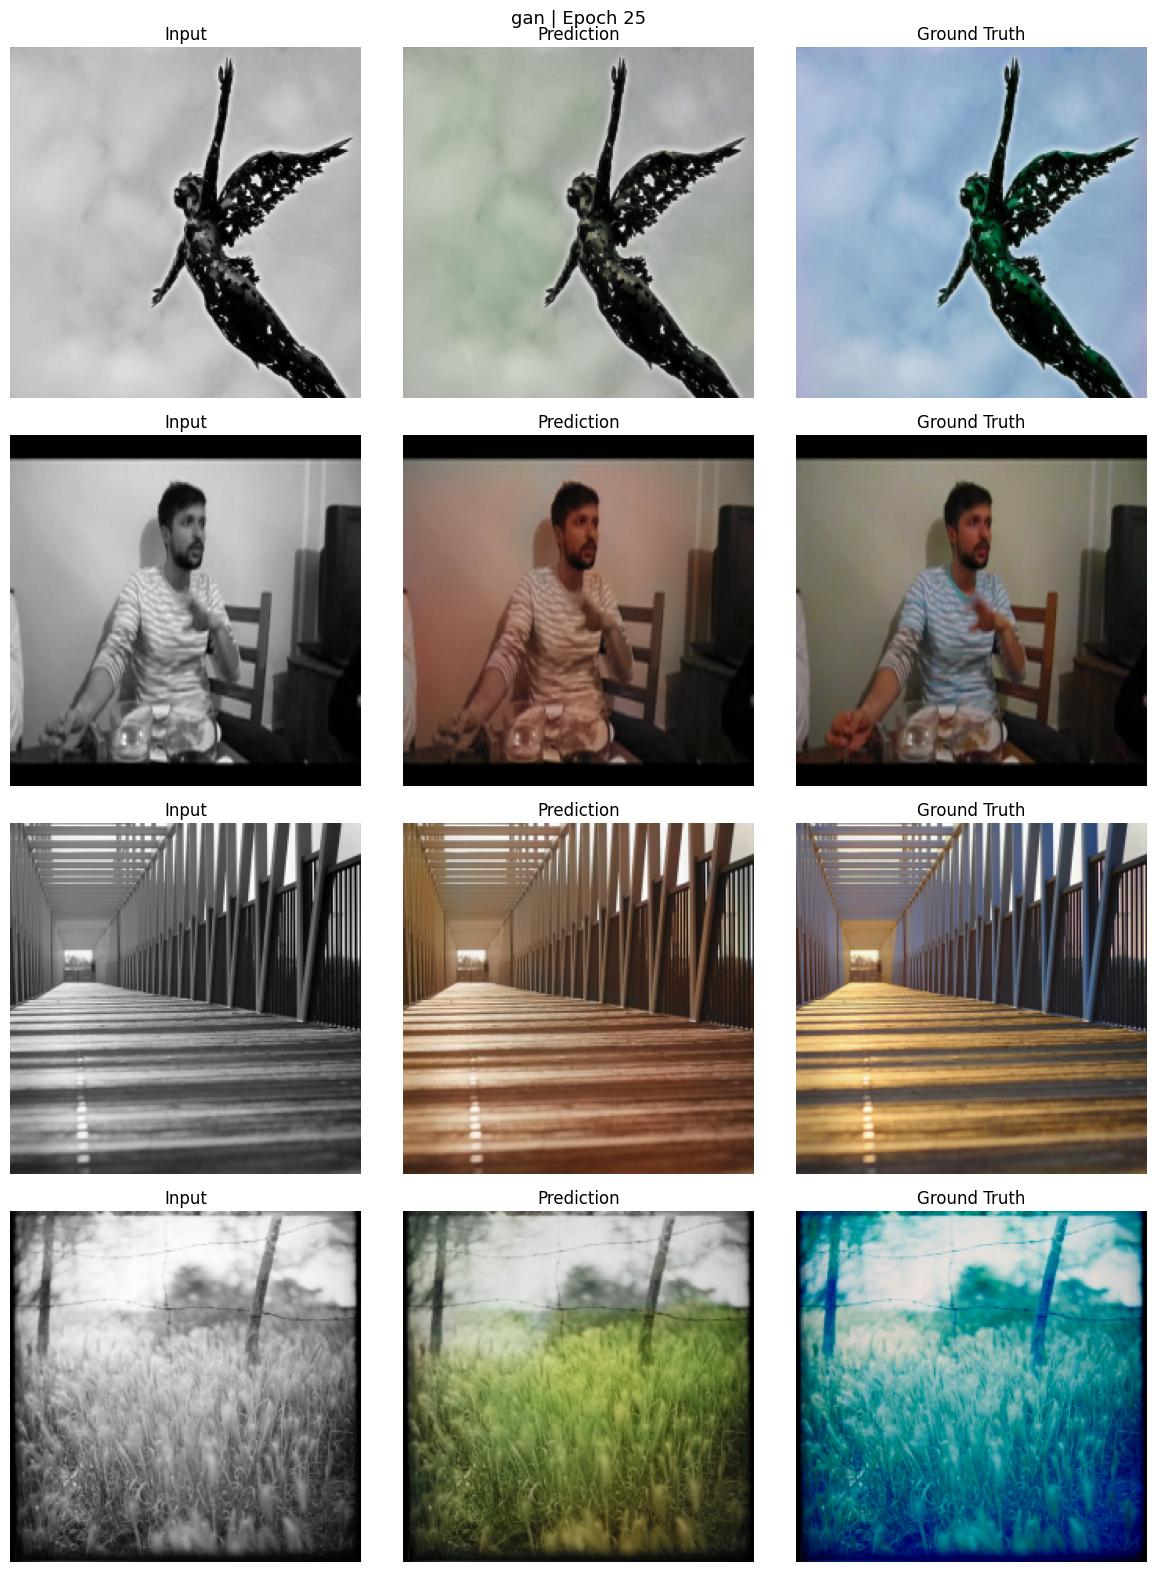

Saved: ./models_gan/gan_epoch_0025.pt


GAN 26/30: 100%|██████████| 104/104 [00:53<00:00,  1.93it/s, D=0.4025, G=4.7284, l1=0.04522]


GAN Epoch 26 | G=4.7284 | D=0.4025 | L1=0.04522 | Val L1=0.07903


GAN 27/30: 100%|██████████| 104/104 [00:54<00:00,  1.92it/s, D=0.3864, G=4.7372, l1=0.04446]


GAN Epoch 27 | G=4.7372 | D=0.3864 | L1=0.04446 | Val L1=0.07971


...

GAN Epoch 28 | G=4.9127 | D=0.4919 | L1=0.04491 | Val L1=0.08043


GAN 29/30: 100%|██████████| 104/104 [00:53<00:00,  1.94it/s, D=0.4831, G=4.8327, l1=0.04421]


GAN Epoch 29 | G=4.8327 | D=0.4831 | L1=0.04421 | Val L1=0.07963


GAN 30/30: 100%|██████████| 104/104 [00:53<00:00,  1.95it/s, D=0.4559, G=4.7172, l1=0.04349]


GAN Epoch 30 | G=4.7172 | D=0.4559 | L1=0.04349 | Val L1=0.08180


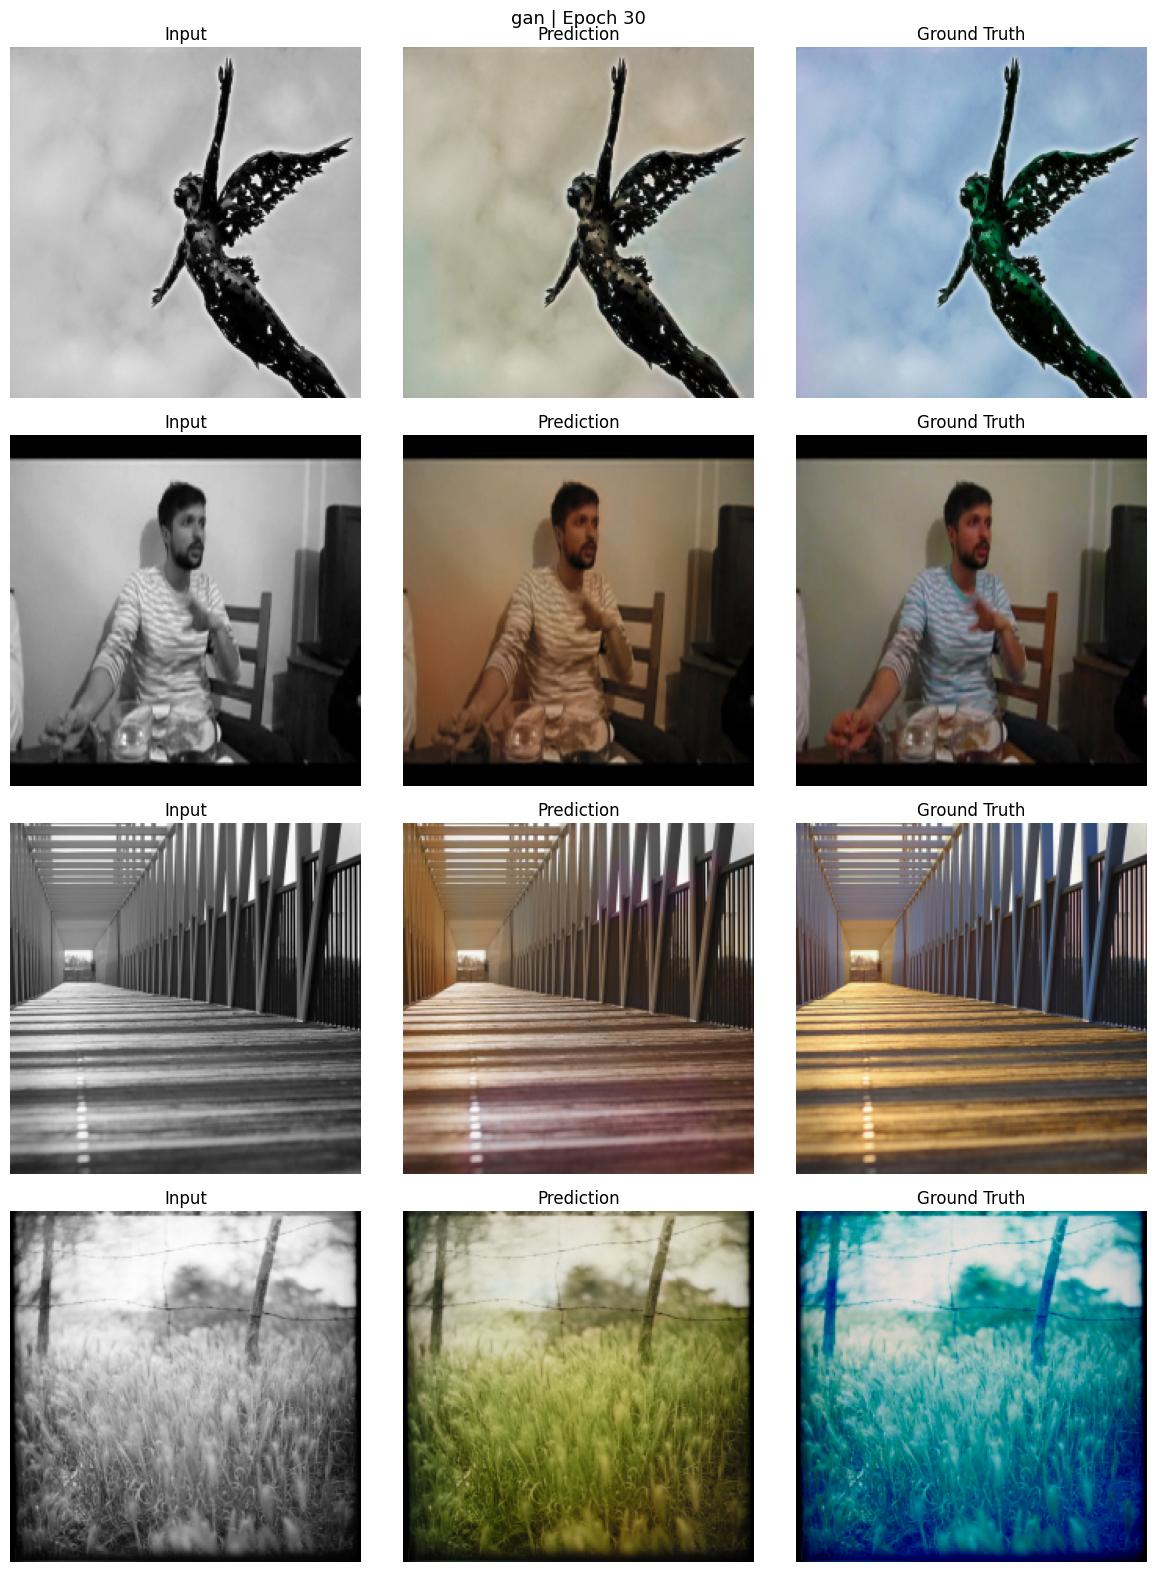

Saved: ./models_gan/gan_epoch_0030.pt
Saved: ./models_gan/gan_final.pt
GAN training complete.


In [ ]:
# Load the pretrained weights to start Stage 2
pretrain_ckpt = os.path.join(CHECKPOINT_DIR, 'pretrained_generator.pt')

net_G.load_state_dict(torch.load(pretrain_ckpt, map_location=device, weights_only=False))
print('Loaded pretrained generator.')


opt_G = optim.Adam(net_G.parameters(), lr=LR_G, betas=(0.5, 0.999))
opt_D = optim.Adam(net_D.parameters(), lr=LR_D, betas=(0.5, 0.999))

gan_start = 0

print('=' * 55)
print('STAGE 2 — GAN Fine-tuning (GAN + L1 loss)')
print('=' * 55)

for epoch in range(gan_start, GAN_EPOCHS):
    net_G.train()
    net_D.train()
    g_losses, d_losses, l1_losses = [], [], []

    pbar = tqdm(train_loader, desc=f'GAN {epoch+1}/{GAN_EPOCHS}')

    for batch in pbar:
        L_b  = batch['L'].to(device, non_blocking=True)
        ab_b = batch['ab'].to(device, non_blocking=True)

        with torch.autocast(device_type='cuda', dtype=AMP_DTYPE):
            ab_fake = net_G(L_b)


        for p in net_D.parameters():
            p.requires_grad_(True)

        with torch.autocast(device_type='cuda', dtype=AMP_DTYPE):
            fake_image = torch.cat([L_b, ab_fake.detach()], dim=1)
            real_image = torch.cat([L_b, ab_b], dim=1)

            # Combined input for PatchGAN
            d_input = torch.cat([fake_image, real_image], dim=0)
            d_out = net_D(d_input)
            d_fake, d_real = d_out.chunk(2, dim=0)

            loss_D = (gan_loss(d_fake, False) + gan_loss(d_real, True)) * 0.5

        opt_D.zero_grad(set_to_none=True)
        loss_D.backward()
        opt_D.step()


        for p in net_D.parameters():
            p.requires_grad_(False) 

        with torch.autocast(device_type='cuda', dtype=AMP_DTYPE):
            fake_image_g = torch.cat([L_b, ab_fake], dim=1)

            loss_G_GAN = gan_loss(net_D(fake_image_g), True)
            loss_G_L1  = l1_loss(ab_fake, ab_b) * LAMBDA_L1
            loss_G = loss_G_GAN + loss_G_L1

        opt_G.zero_grad(set_to_none=True)
        loss_G.backward()
        opt_G.step()

        g_losses.append(loss_G.item())
        d_losses.append(loss_D.item())
        l1_losses.append(loss_G_L1.item() / LAMBDA_L1)

        pbar.set_postfix(
            G=f'{np.mean(g_losses):.4f}',
            D=f'{np.mean(d_losses):.4f}',
            l1=f'{np.mean(l1_losses):.5f}'
        )


    net_G.eval()
    val_l1_ep = []
    with torch.no_grad(), torch.autocast(device_type='cuda', dtype=AMP_DTYPE):
        for batch in val_loader:
            L_b  = batch['L'].to(device, non_blocking=True)
            ab_b = batch['ab'].to(device, non_blocking=True)
            val_l1_ep.append(l1_loss(net_G(L_b), ab_b).item())

    avg_G, avg_D, avg_l1, avg_val = np.mean(g_losses), np.mean(d_losses), np.mean(l1_losses), np.mean(val_l1_ep)

    train_losses.append({'l1': avg_l1, 'G': avg_G, 'D': avg_D})
    val_losses.append({'l1': avg_val, 'G': None, 'D': None})

    print(f'GAN Epoch {epoch+1} | G={avg_G:.4f} | D={avg_D:.4f} | L1={avg_l1:.5f} | Val L1={avg_val:.5f}')


    if (epoch + 1) % SAMPLE_EVERY == 0:
        visualize_samples(net_G, val_loader, epoch + 1, tag='gan')

print('GAN training complete.')

## Plotting   Training Curves

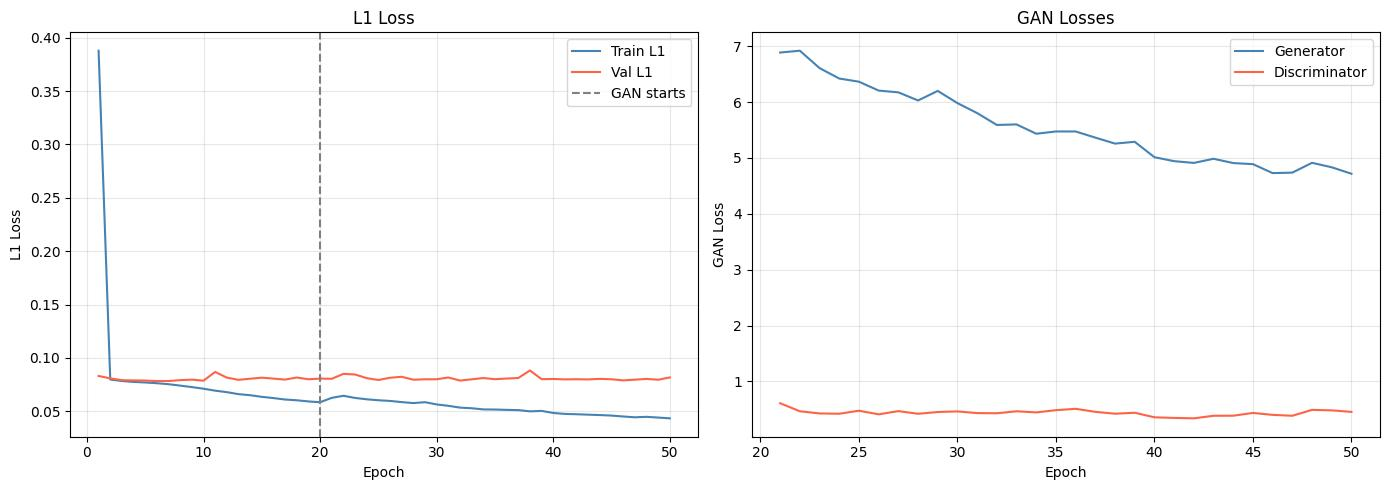

Best val L1: 0.07840 at epoch 6


In [14]:
def plot_curves():
    train_l1 = [d['l1'] for d in train_losses if d['l1'] is not None]
    val_l1   = [d['l1'] for d in val_losses   if d['l1'] is not None]
    g_vals   = [d['G']  for d in train_losses if d['G']  is not None]
    d_vals   = [d['D']  for d in train_losses if d['D']  is not None]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(range(1, len(train_l1)+1), train_l1, label='Train L1', color='steelblue')
    axes[0].plot(range(1, len(val_l1)+1),   val_l1,   label='Val L1',   color='tomato')
    axes[0].axvline(x=PRETRAIN_EPOCHS, color='gray', linestyle='--', label='GAN starts')
    axes[0].set(xlabel='Epoch', ylabel='L1 Loss', title='L1 Loss')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    if g_vals:
        gan_epochs = range(PRETRAIN_EPOCHS + 1, PRETRAIN_EPOCHS + len(g_vals) + 1)
        axes[1].plot(gan_epochs, g_vals, label='Generator',     color='steelblue')
        axes[1].plot(gan_epochs, d_vals, label='Discriminator', color='tomato')
        axes[1].set(xlabel='Epoch', ylabel='GAN Loss', title='GAN Losses')
        axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{CHECKPOINT_DIR}/training_curves.png', dpi=100)
    plt.show()

    if val_l1:
        best = min(val_l1)
        print(f'Best val L1: {best:.5f} at epoch {val_l1.index(best)+1}')

plot_curves()


## Evaluate PSNR and SSIM

In [15]:
evaluate(net_G, val_loader)


100%|██████████| 14/14 [01:06<00:00,  4.73s/it]

PSNR: 22.840 dB | SSIM: 0.8866


(np.float64(22.840080620600954), np.float64(0.8865786516693887))

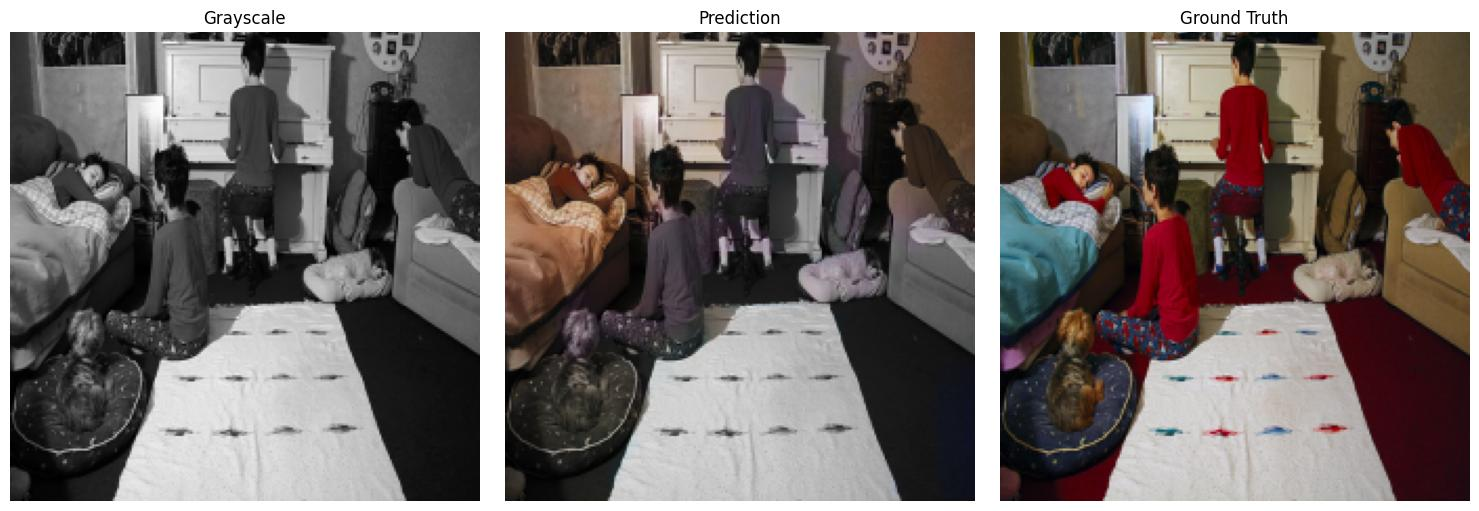

In [28]:
net_G.eval()
batch = next(iter(val_loader))
idx   = 170

L_img = batch['L'][idx].unsqueeze(0).to(device)
ab_gt = batch['ab'][idx]

with torch.no_grad(), torch.autocast(device_type='cuda', dtype=AMP_DTYPE):
    ab_pred = net_G(L_img)[0].float().cpu()

pred_rgb = np.clip(tensors_to_rgb(batch['L'][idx], ab_pred), 0, 1)
true_rgb = np.clip(tensors_to_rgb(batch['L'][idx], ab_gt),   0, 1)
gray     = (batch['L'][idx].squeeze() + 1) / 2

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1); plt.imshow(gray, cmap='gray'); plt.title('Grayscale');    plt.axis('off')
plt.subplot(1, 3, 2); plt.imshow(pred_rgb);          plt.title('Prediction');   plt.axis('off')
plt.subplot(1, 3, 3); plt.imshow(true_rgb);          plt.title('Ground Truth'); plt.axis('off')
plt.tight_layout()
plt.show()
